In [39]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 데이터 불러오기
train_df = pd.read_parquet('../data/Data/train_df_cleaned.parquet')

In [ ]:
# train_df = train_df[['카드이용한도금액','CA한도금액',
#          '이용건수_선결제_R3M',
#         '선입금원금_B2M','상환개월수_결제일_R3M',
#         '선입금원금_B5M','이용개월수_결제일_R6M']]

# train_df

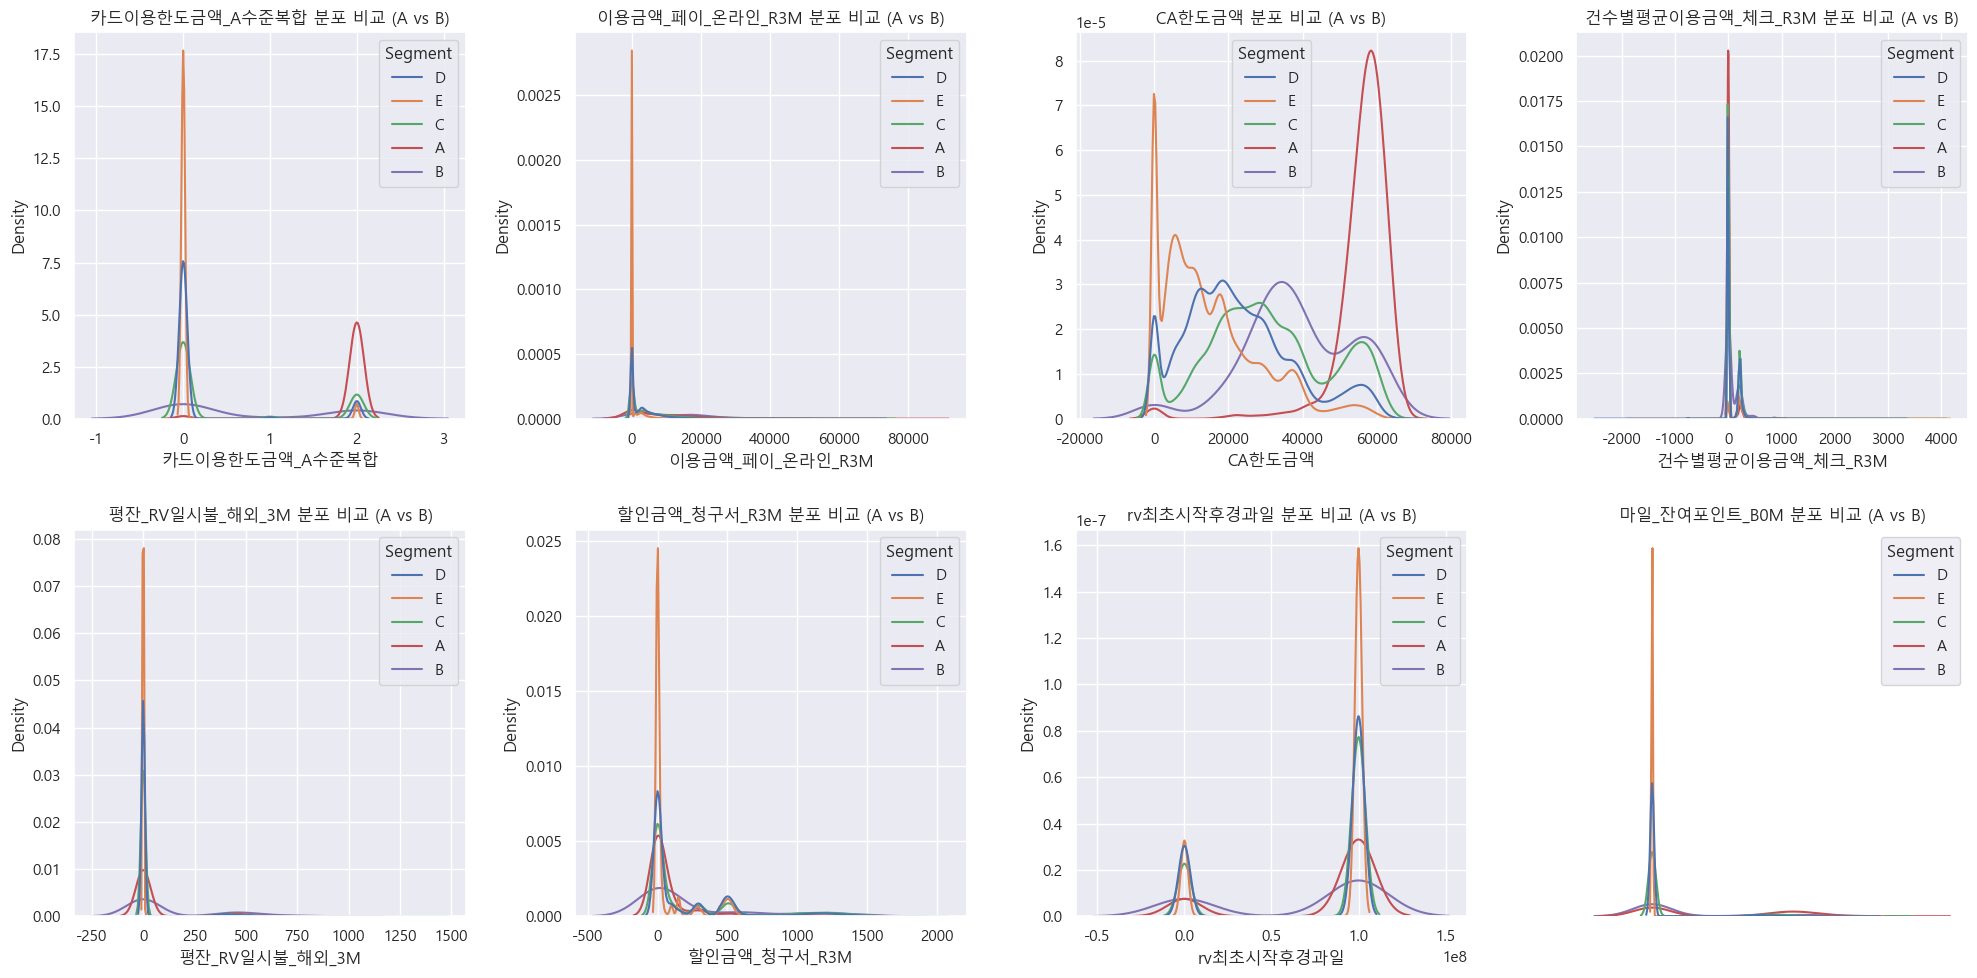

In [ ]:
features = train_df[['카드이용한도금액_A수준복합','이용금액_페이_온라인_R3M','CA한도금액',
                    '건수별평균이용금액_체크_R3M','평잔_RV일시불_해외_3M','할인금액_청구서_R3M',
                    'rv최초시작후경과일','마일_잔여포인트_B0M']]

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.kdeplot(data=train_df, x=f, hue='Segment', common_norm=False)
    plt.title(f'{f} 분포 비교 (A vs B)')

plt.tight_layout()
plt.show()

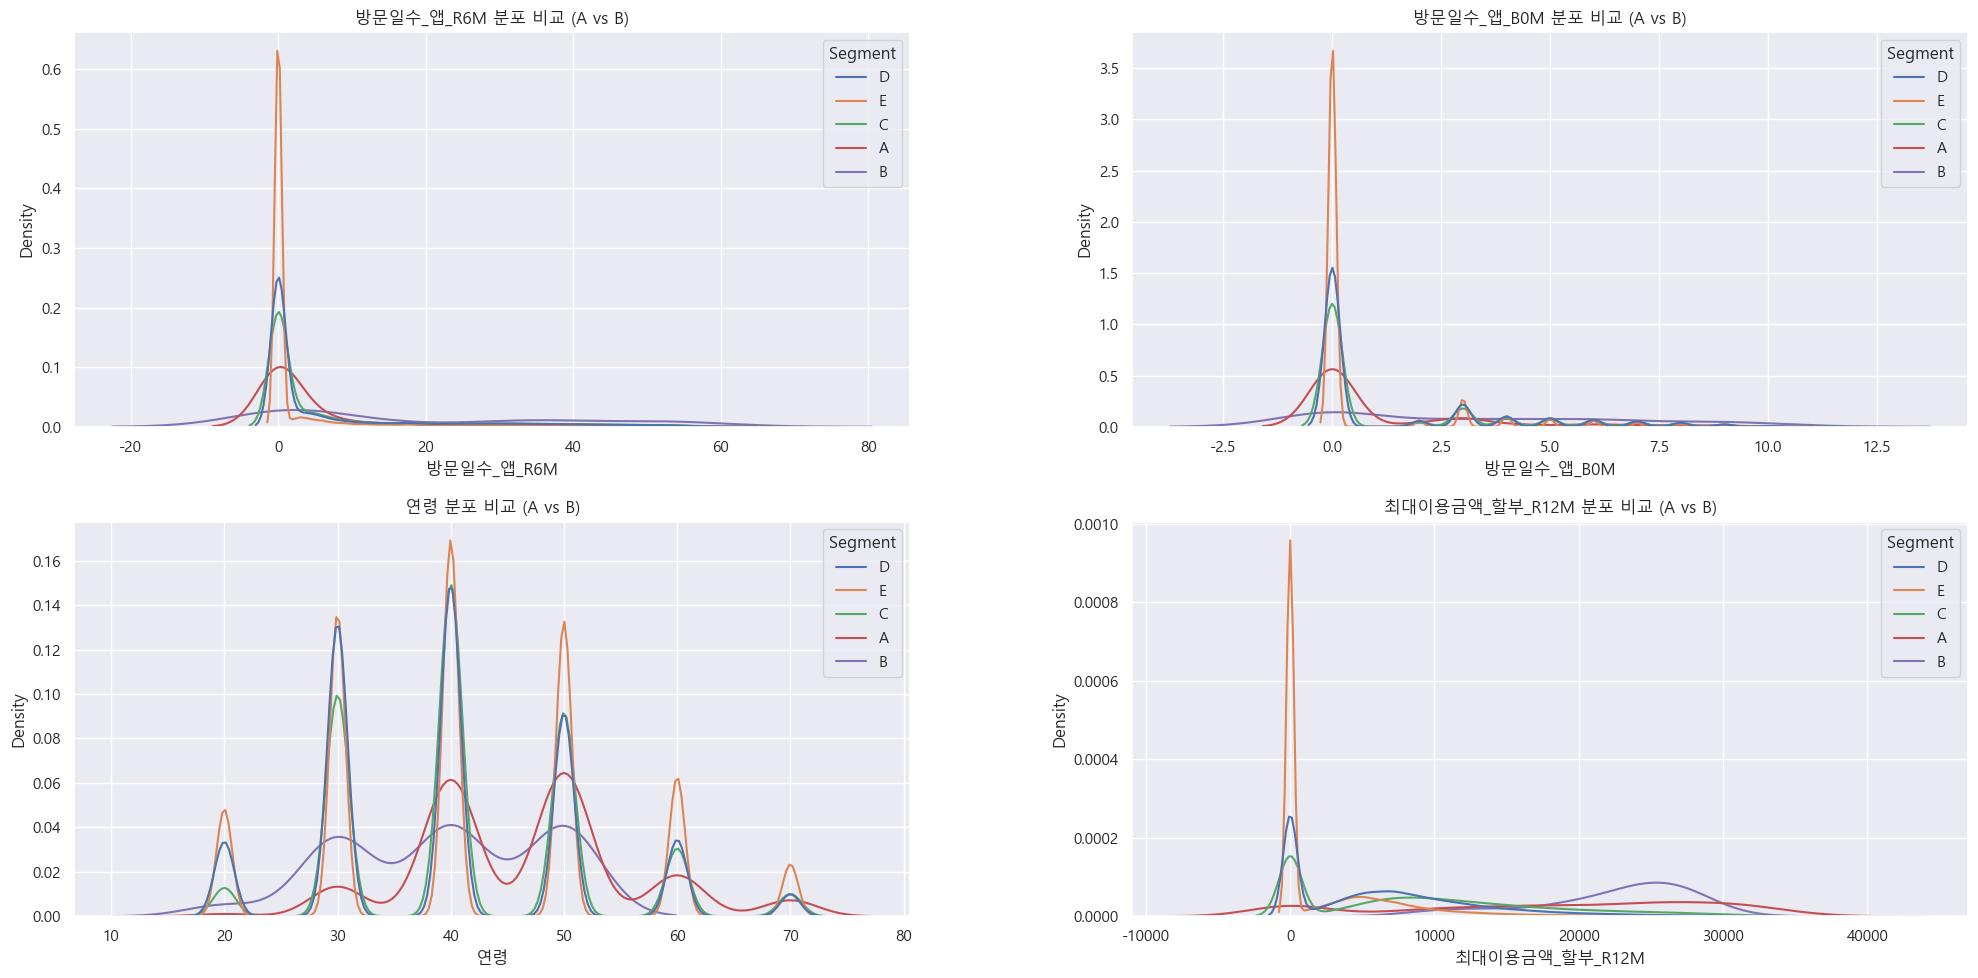

In [7]:
features = train_df[['방문일수_앱_R6M','방문일수_앱_B0M','연령','최대이용금액_할부_R12M']]

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(data=train_df, x=f, hue='Segment', common_norm=False)
    plt.title(f'{f} 분포 비교 (A vs B)')


plt.subplot(2, 4, 8).axis('off')

plt.tight_layout()
plt.show()

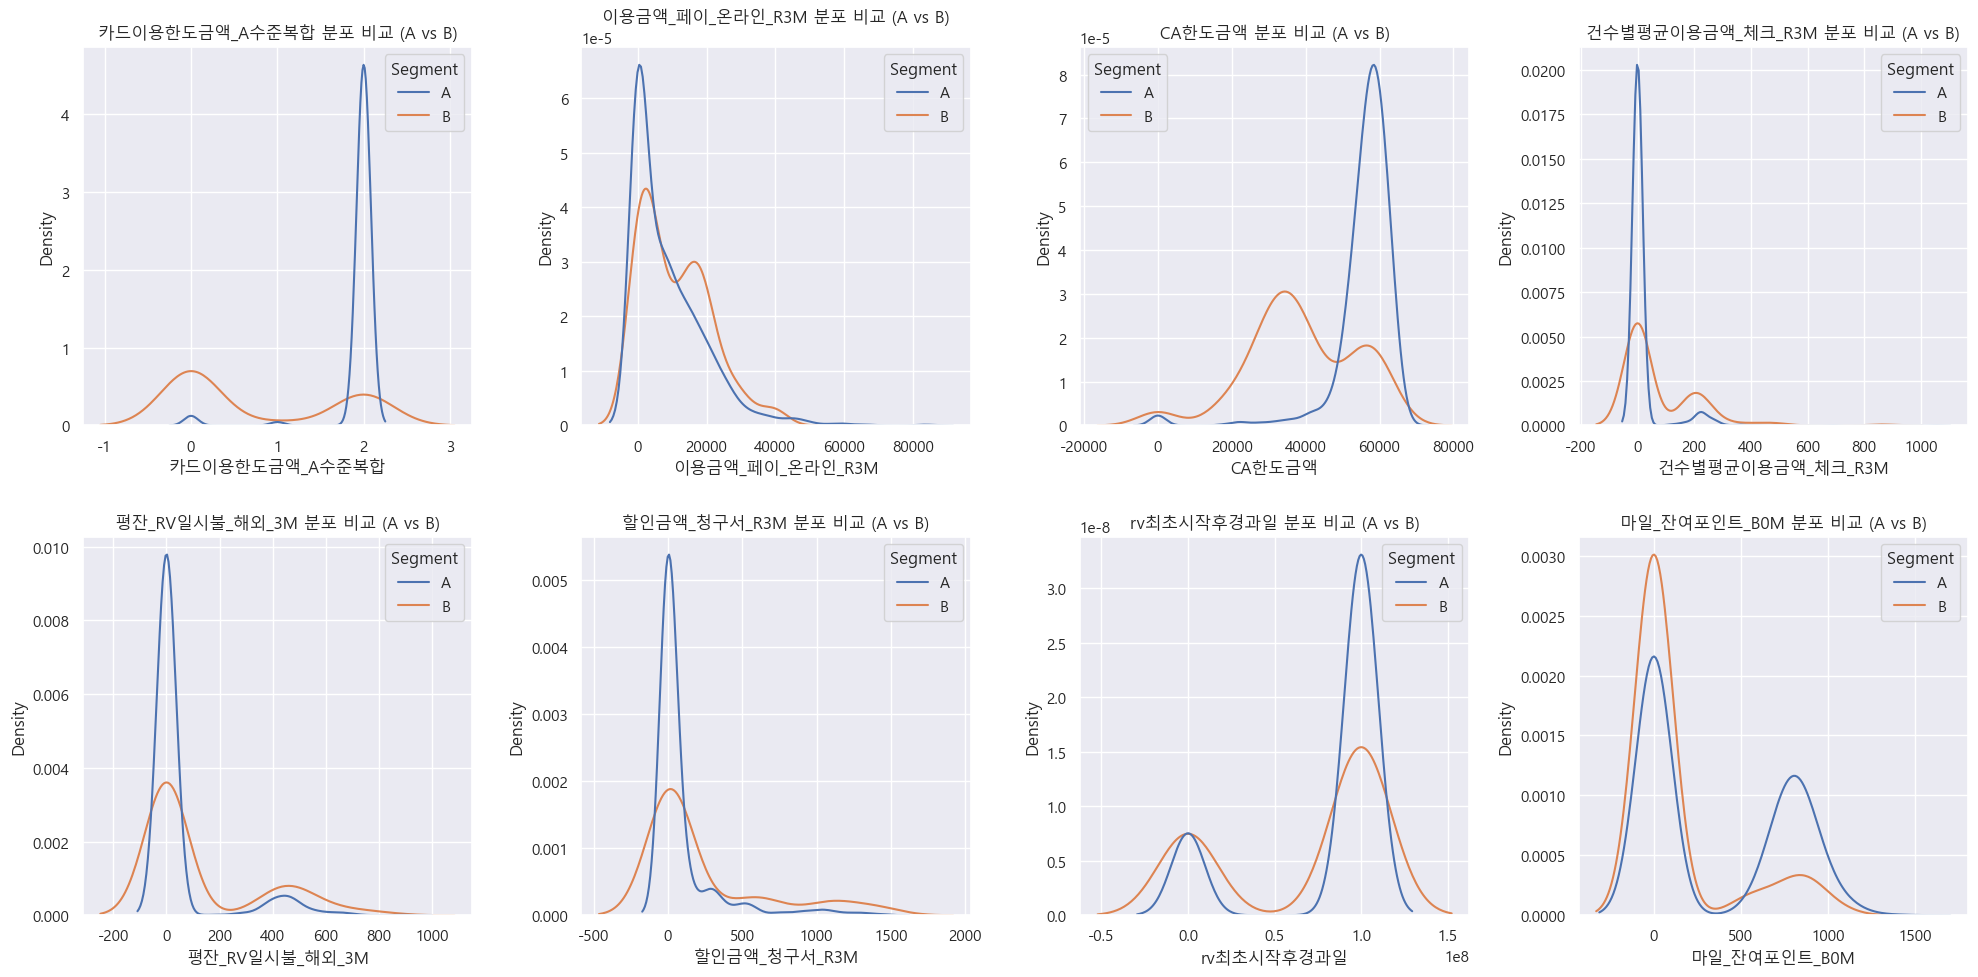

In [10]:
# Segment가 'A', 'B'인 데이터만 필터링
ab_df = train_df[train_df['Segment'].isin(['A', 'B'])].copy()

features = ['카드이용한도금액_A수준복합','이용금액_페이_온라인_R3M','CA한도금액',
            '건수별평균이용금액_체크_R3M','평잔_RV일시불_해외_3M','할인금액_청구서_R3M',
            'rv최초시작후경과일','마일_잔여포인트_B0M']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    # 해당 feature에 결측값이 있을 경우 에러가 발생하므로 dropna
    sns.kdeplot(data=ab_df.dropna(subset=[f]), x=f, hue='Segment', common_norm=False)
    plt.title(f'{f} 분포 비교 (A vs B)')

plt.tight_layout()
plt.show()


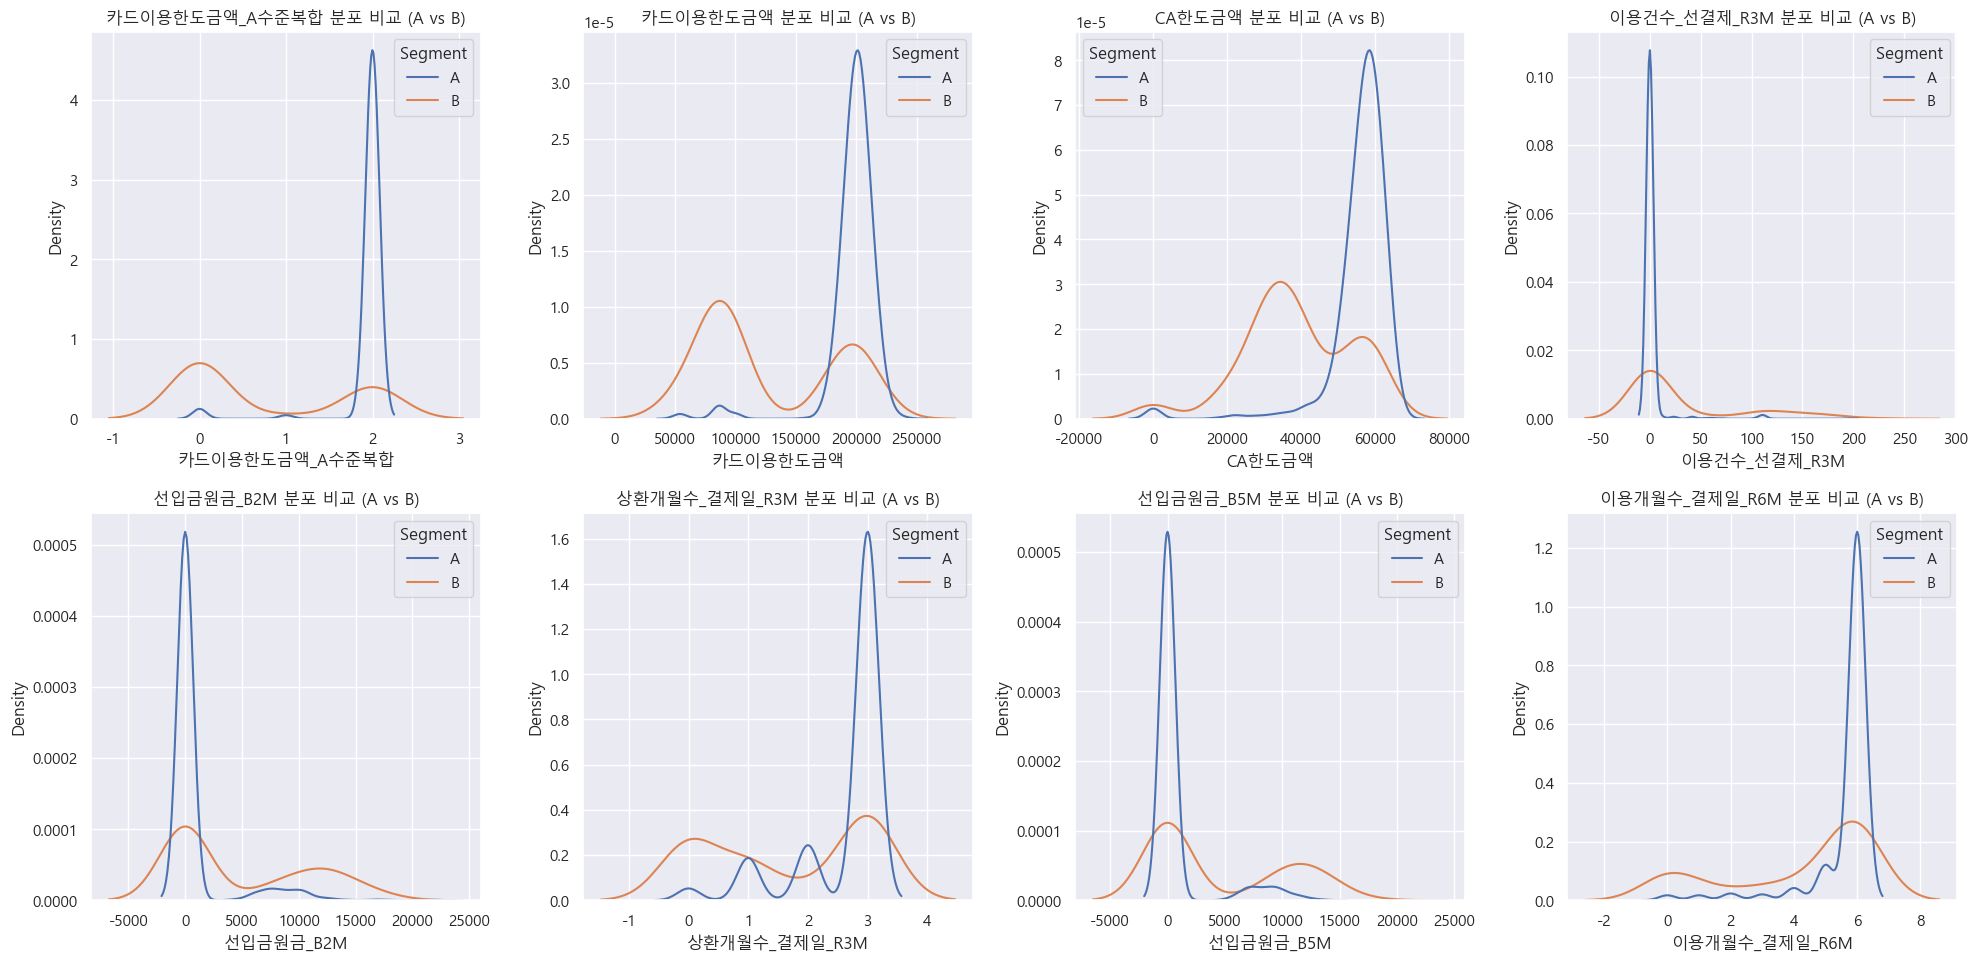

In [11]:
# Segment가 'A', 'B'인 데이터만 필터링
ab_df = train_df[train_df['Segment'].isin(['A', 'B'])].copy()

features = ['카드이용한도금액_A수준복합','카드이용한도금액','CA한도금액','이용건수_선결제_R3M',
            '선입금원금_B2M','상환개월수_결제일_R3M',
            '선입금원금_B5M','이용개월수_결제일_R6M']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    # 해당 feature에 결측값이 있을 경우 에러가 발생하므로 dropna
    sns.kdeplot(data=ab_df.dropna(subset=[f]), x=f, hue='Segment', common_norm=False)
    plt.title(f'{f} 분포 비교 (A vs B)')

plt.tight_layout()
plt.show()


In [ ]:
# Segment가 'A', 'B'인 데이터만 필터링
ab_df = train_df[train_df['Segment'].isin(['A', 'B'])].copy()

features = []

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    # 해당 feature에 결측값이 있을 경우 에러가 발생하므로 dropna
    sns.kdeplot(data=ab_df.dropna(subset=[f]), x=f, hue='Segment', common_norm=False)
    plt.title(f'{f} 분포 비교 (A vs B)')

plt.tight_layout()
plt.show()


In [19]:
train_df[['Segment','쇼핑_총이용금액']]

,Segment,쇼핑_총이용금액
0,D,242
1,E,1956
2,C,9550
3,D,1288
4,E,0
...,...,...
2399995,E,0
2399996,D,2556
2399997,C,2463
2399998,E,0


In [ ]:
쇼핑_총이용금액, 교통_총이용금액, 여유_총이용금액, 납부_총이용금액

In [24]:
cols = [
    '쇼핑_총이용금액',
    '교통_총이용금액',
    '여유_총이용금액',
    '납부_총이용금액'
]

def summarize_columns_by_segment(df, columns, segment_col='Segment'):
    results = {}
    for col in columns:
        summary = (
            df.groupby(segment_col)[col]
            .agg([
                ('count', 'count'),
                ('mean', 'mean'),
                ('median', 'median'),
                ('min', 'min'),
                ('max', 'max'),
                ('num_zeros', lambda x: (x == 0).sum())
            ])
        )
        summary['zero_ratio (%)'] = (summary['num_zeros'] / summary['count']) * 100
        summary = summary[['count', 'mean', 'median', 'min', 'max', 'num_zeros', 'zero_ratio (%)']]
        summary = summary.round(2)
        results[col] = summary
    return results

# 실행
summaries = summarize_columns_by_segment(train_df, cols)

# 결과 예시 출력
for col_name, summary_df in summaries.items():
    print(f"\n[{col_name}] 통계 요약\n")
    print(summary_df)


[쇼핑_총이용금액] 통계 요약

           count      mean   median   min     max  num_zeros  zero_ratio (%)
Segment                                                                     
A            972  22148.75  16943.5     0  137762         45            4.63
B            144  26767.62  21617.5  1425   89762          0            0.00
C         127590  10991.41   7855.0     0  121136      13284           10.41
D         349242   6967.33   5020.0     0  140745      46368           13.28
E        1922052   2075.10    657.0     0   84957     862966           44.90

[교통_총이용금액] 통계 요약

           count     mean  median  min    max  num_zeros  zero_ratio (%)
Segment                                                                 
A            972  3626.35  3773.5    0   8453         85            8.74
B            144  3292.10  3281.0    0   9034         16           11.11
C         127590  2627.08  2473.0    0  15516      20854           16.34
D         349242  1953.22  1840.0    0  13557      73248  

In [29]:
cols = [
    '쇼핑_총이용금액',
    '교통_총이용금액',
    '여유_총이용금액',
    '납부_총이용금액'
]

summary = train_df[cols].describe().T.round(2)
print(summary)

              count     mean      std  min  25%     50%     75%       max
쇼핑_총이용금액  2400000.0  3270.63  5566.92  0.0  0.0  1320.0  4165.0  140745.0
교통_총이용금액  2400000.0   975.28  1370.51  0.0  0.0   205.0  1761.0   15516.0
여유_총이용금액  2400000.0   145.39   400.02  0.0  0.0     0.0     0.0    7003.0
납부_총이용금액  2400000.0  1016.40  1711.92  0.0  0.0     0.0  1697.0   14291.0


In [ ]:
# 테마 설정 (스타일과 색감)
# sns.set_theme(style="whitegrid", palette="Blues")

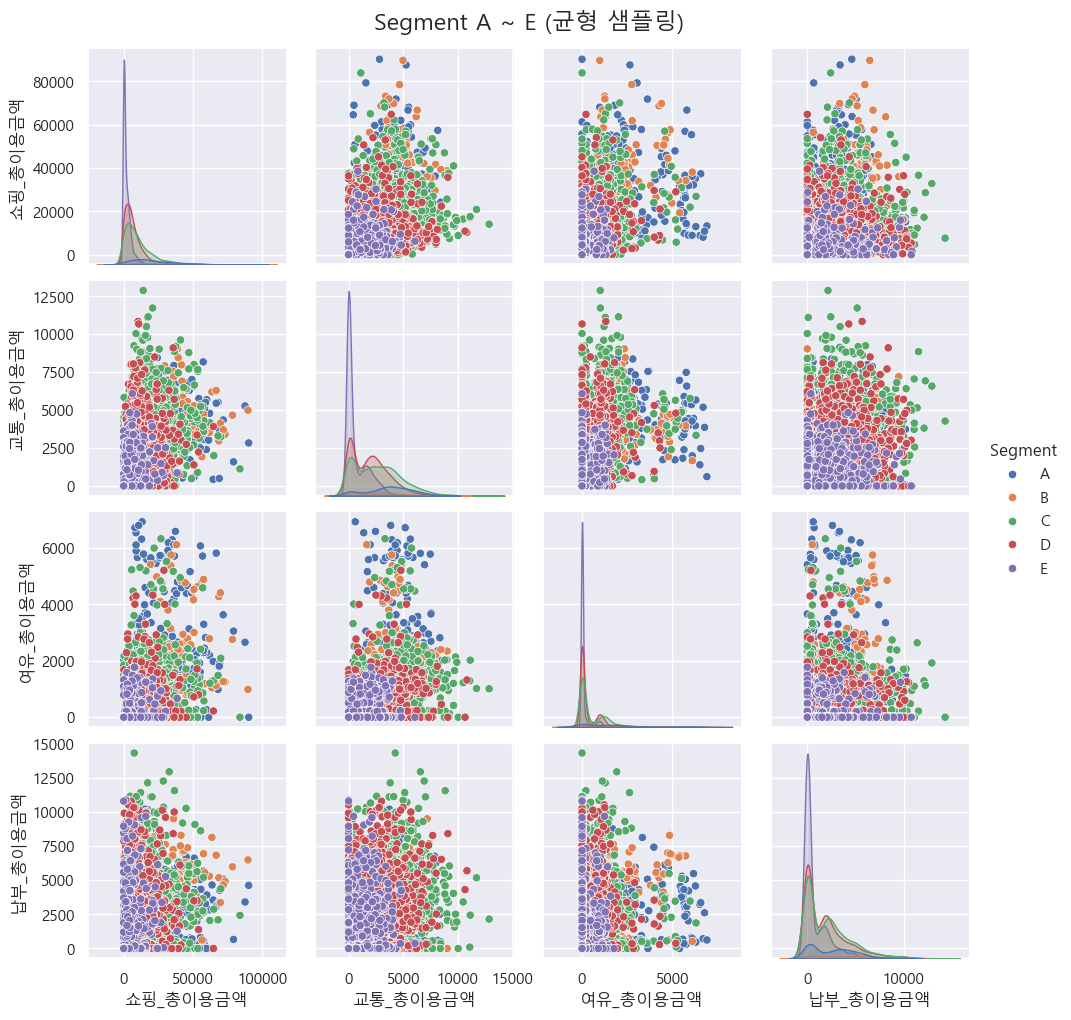

In [22]:
# 변수 리스트
# cols = [
#     '할부금액총합_유이자_R12M',
#     '할부건수총합_무이자_R12M',
#     '할부금액총합_무이자_R12M'
# ]

cols = [
    '쇼핑_총이용금액',
    '교통_총이용금액',
    '여유_총이용금액',
    '납부_총이용금액'
]

# 세그먼트별 샘플수 설정
sample_counts = {
    'A': 500,
    'B': 500,
    'C': 2000,
    'D': 2000,
    'E': 2000
}

# 세그먼트별 샘플링
sampled_segments = []
for segment, count in sample_counts.items():
    subset = train_df[train_df['Segment'] == segment]
    if len(subset) <= count:
        sampled = subset
    else:
        sampled = subset.sample(n=count, random_state=42)
    sampled_segments.append(sampled)

# 하나로 합치기
balanced_df = pd.concat(sampled_segments)

# pairplot 그리기
sns.pairplot(data=balanced_df, vars=cols, hue='Segment')
plt.suptitle("Segment A ~ E (균형 샘플링)", y=1.02)
plt.show()


In [36]:
cols = [
    '카드이용한도금액_A수준복합',
    '카드이용한도금액_B1M',
    '이용금액_페이_온라인_R3M',
    'CA한도금액',
    '건수별평균이용금액_체크_R3M'
]

summary = train_df[cols].describe().round(2)
summary

,카드이용한도금액_A수준복합,카드이용한도금액_B1M,이용금액_페이_온라인_R3M,CA한도금액,건수별평균이용금액_체크_R3M
count,2400000.00,2400000.00,2400000.00,2400000.00,2400000.00
mean,0.12,51702.67,1253.13,17214.79,31.04
std,0.47,45863.85,3087.18,14371.24,95.76
min,0.00,0.00,0.00,0.00,-2490.00
25%,0.00,20779.00,0.00,5930.00,0.00
50%,0.00,37011.00,0.00,14063.00,0.00
75%,0.00,70686.00,729.00,25512.00,0.00
max,2.00,252618.00,83631.00,67723.00,4152.00


In [37]:
def summarize_columns_by_segment(df, columns, segment_col='Segment'):
    results = {}
    for col in columns:
        summary = (
            df.groupby(segment_col)[col]
            .agg([
                ('count', 'count'),
                ('mean', 'mean'),
                ('median', 'median'),
                ('min', 'min'),
                ('max', 'max'),
                ('num_zeros', lambda x: (x == 0).sum())
            ])
        )
        summary['zero_ratio (%)'] = (summary['num_zeros'] / summary['count']) * 100
        summary = summary[['count', 'mean', 'median', 'min', 'max', 'num_zeros', 'zero_ratio (%)']]
        summary = summary.round(2)
        results[col] = summary
    return results

# 실행
summaries = summarize_columns_by_segment(train_df, cols)

# 결과 예시 출력
for col_name, summary_df in summaries.items():
    print(f"\n[{col_name}] 통계 요약\n")
    print(summary_df)


[카드이용한도금액_A수준복합] 통계 요약

           count  mean  median  min  max  num_zeros  zero_ratio (%)
Segment                                                            
A            972  1.94     2.0    0    2         25            2.57
B            144  0.74     0.0    0    2         88           61.11
C         127590  0.49     0.0    0    2      95195           74.61
D         349242  0.21     0.0    0    2     311560           89.21
E        1922052  0.08     0.0    0    2    1840013           95.73

[카드이용한도금액_B1M] 통계 요약

           count       mean    median    min     max  num_zeros  \
Segment                                                           
A            972  197902.48  199927.0  64529  250199          0   
B            144  123225.83   83643.0  58932  220321          0   
C         127590   97536.93   76722.0      0  250466       1078   
D         349242   68923.32   62900.0      0  252618       3656   
E        1922052   45451.76   35859.0      0  238288      91022   

      

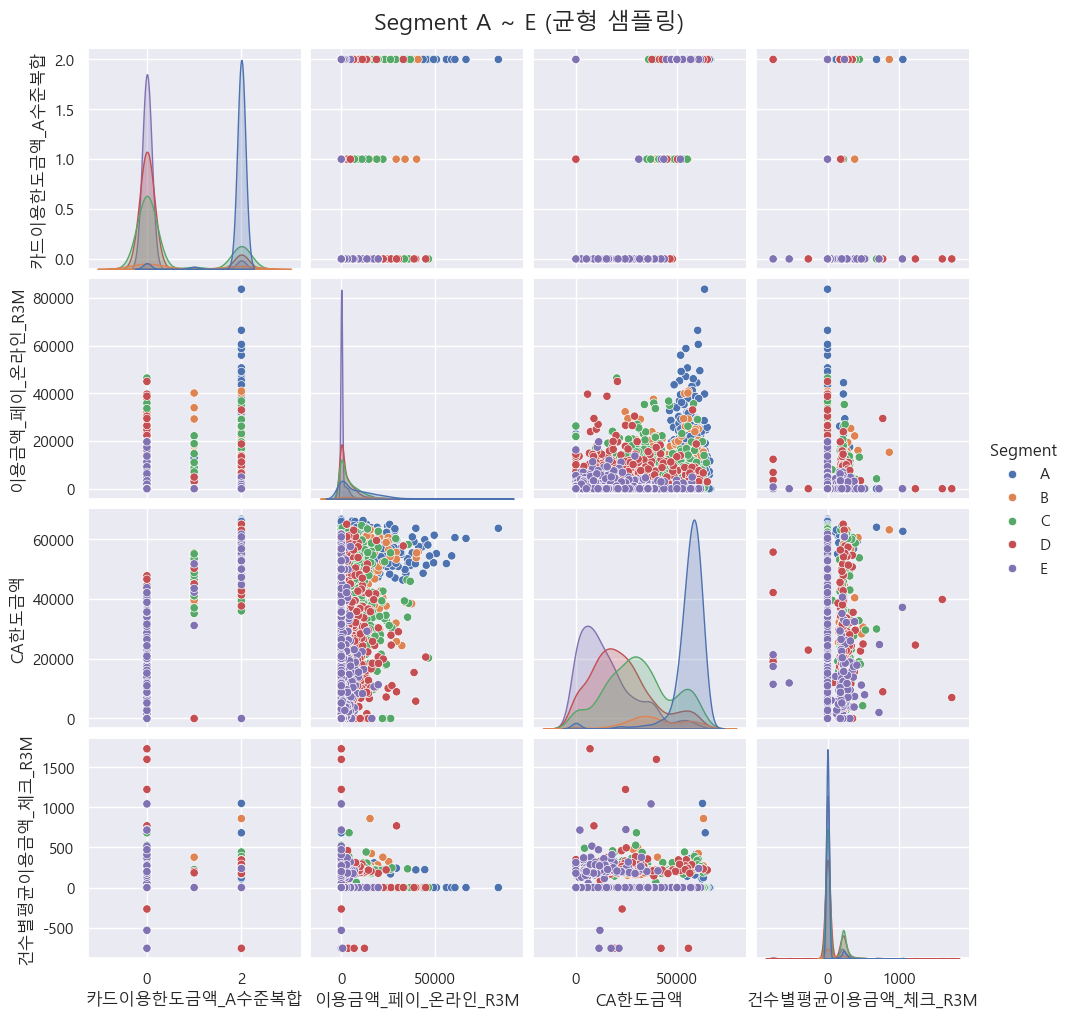

In [ ]:
cols = [
    '카드이용한도금액_A수준복합',
    '이용금액_페이_온라인_R3M',
    'CA한도금액',
    '건수별평균이용금액_체크_R3M'
]

# 세그먼트별 샘플수 설정
sample_counts = {
    'A': 900,
    'B': 500,
    'C': 1000,
    'D': 1000,
    'E': 1000
}

# 세그먼트별 샘플링
sampled_segments = []
for segment, count in sample_counts.items():
    subset = train_df[train_df['Segment'] == segment]
    if len(subset) <= count:
        sampled = subset
    else:
        sampled = subset.sample(n=count, random_state=42)
    sampled_segments.append(sampled)

# 하나로 합치기
balanced_df = pd.concat(sampled_segments)

# pairplot 그리기
sns.pairplot(data=balanced_df, vars=cols, hue='Segment')
plt.suptitle("Segment A ~ E (균형 샘플링)", y=1.02)
plt.show()


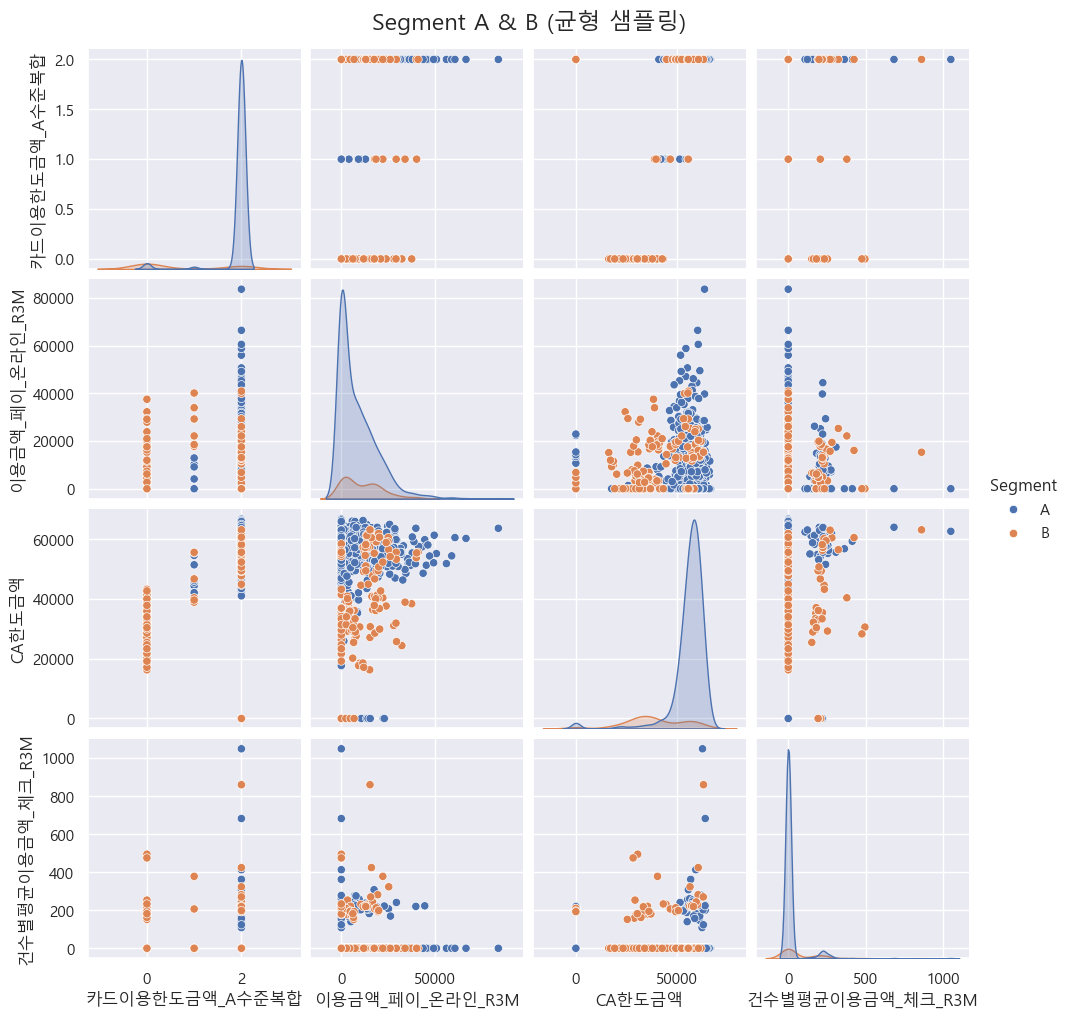

In [31]:
# A, B 세그먼트만 필터링
ab_df = balanced_df[balanced_df['Segment'].isin(['A', 'B'])]

# pairplot 그리기
sns.pairplot(data=ab_df, vars=cols, hue='Segment')
plt.suptitle("Segment A & B (균형 샘플링)", y=1.02)
plt.show()


[요약 통계] 카드이용한도금액_A수준복합


,mean,median,std,count
Segment,,,,
A,1.939300,2.0,0.329495,972
B,0.736111,0.0,0.945997,144
C,0.488432,0.0,0.847901,127590
D,0.207409,0.0,0.602841,349242
E,0.081372,0.0,0.390036,1922052


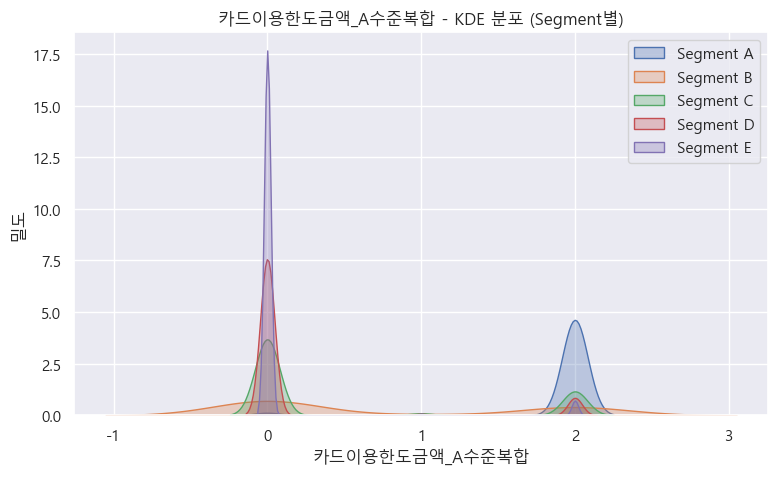


[요약 통계] 이용금액_페이_온라인_R3M


,mean,median,std,count
Segment,,,,
A,8668.500000,5392.5,10694.290208,972
B,11007.430556,8569.5,10172.028993,144
C,4551.942229,2214.0,6346.581984,127590
D,2985.295374,856.0,4433.810500,349242
E,714.928174,0.0,1999.290951,1922052


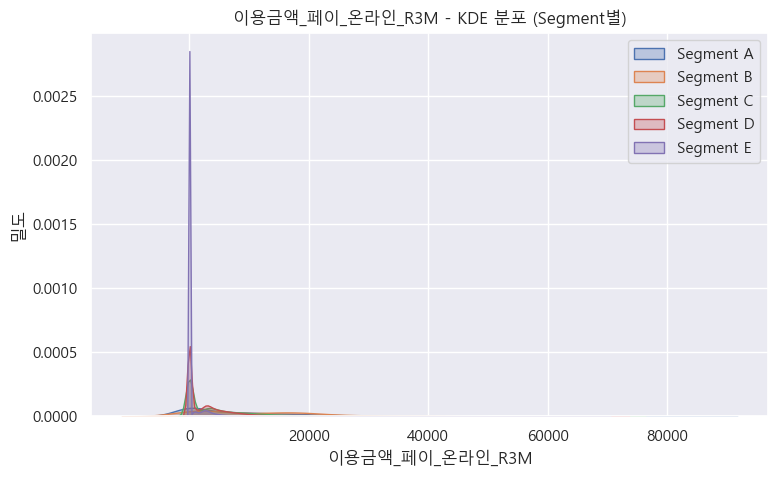


[요약 통계] CA한도금액


,mean,median,std,count
Segment,,,,
A,56036.476337,57666.5,8627.183700,972
B,38753.715278,36932.0,14723.760357,144
C,30767.306795,29186.5,16418.820538,127590
D,22698.301980,20550.0,14695.920465,349242
E,15297.534440,11971.5,13363.009963,1922052


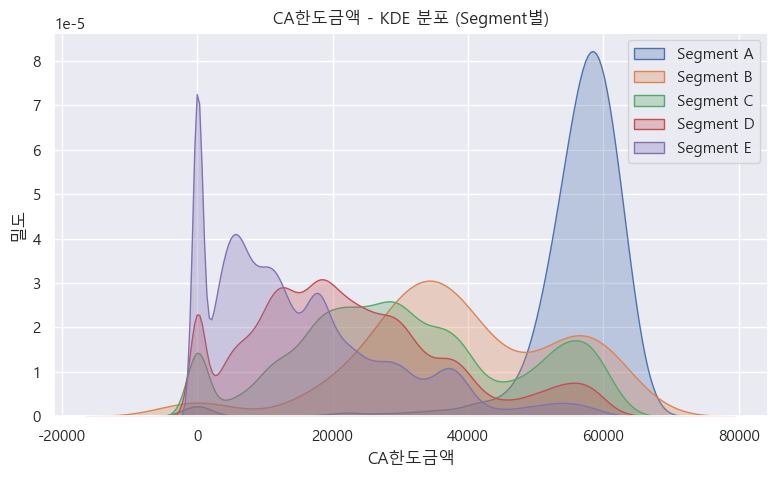


[요약 통계] 건수별평균이용금액_체크_R3M


,mean,median,std,count
Segment,,,,
A,17.839333,0.0,71.829468,972
B,73.785149,0.0,131.541031,144
C,62.111679,0.0,128.625687,127590
D,55.948151,0.0,117.075996,349242
E,24.451267,0.0,89.316612,1922052


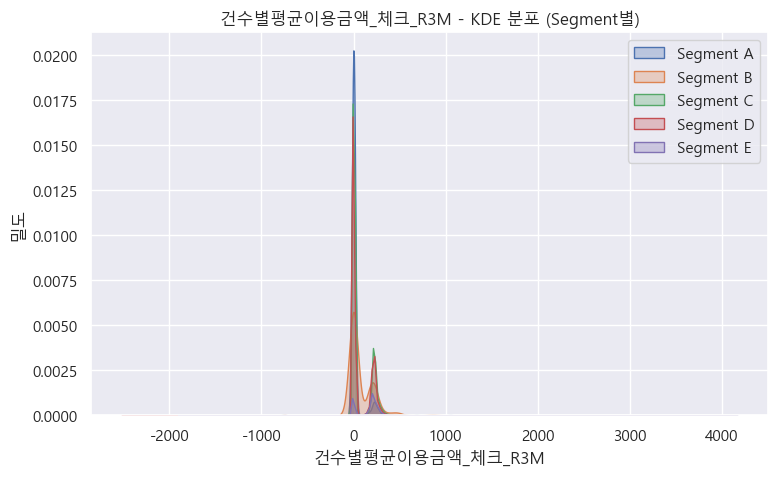

In [41]:

# 비교하고 싶은 컬럼들 입력
cols = [
    '카드이용한도금액_A수준복합',
    '이용금액_페이_온라인_R3M',
    'CA한도금액',
    '건수별평균이용금액_체크_R3M'
]

# Segment 순서 고정
segment_order = ['A', 'B', 'C', 'D', 'E']

# 각 컬럼별 평균/중앙값 요약 + KDE plot
for col in cols:
    if col not in train_df.columns:
        continue

    print(f"\n[요약 통계] {col}")
    display(train_df.groupby('Segment')[col]
            .agg(['mean', 'median', 'std', 'count'])
            .reindex(segment_order))

    plt.figure(figsize=(8, 5))
    for seg in segment_order:
        data = train_df[train_df['Segment'] == seg][col].dropna()
        if len(data) > 0:
            sns.kdeplot(data, label=f'Segment {seg}', fill=True, alpha=0.3)
    
    plt.title(f'{col} - KDE 분포 (Segment별)')
    plt.xlabel(col)
    plt.ylabel('밀도')
    plt.legend()
    plt.tight_layout()
    plt.show()
